# Stroke Prediction Using Machine Learning

## Project Overview

Stroke is one of the leading causes of death and disability worldwide. Predicting the likelihood of a stroke using patient health information can help healthcare providers identify high-risk individuals and support early medical intervention.

This project applies supervised machine learning techniques to predict whether a patient is likely to experience a stroke based on demographic, medical, and lifestyle information.

Since the target variable (`stroke`) has only two possible outcomes (Stroke or No Stroke), this is a **binary classification** problem.

## Objective

To develop and evaluate machine learning models capable of predicting stroke occurrence and identify the factors that contribute most to stroke risk.

## Importing Libraries


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Loading the Dataset


In [221]:
df = pd.read_csv("/home/marlicd/Projects/Machine_Learning/Machine_Learning_Capstone/healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [84]:
df.shape

(5110, 12)

In [223]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [85]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [86]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [224]:
df.duplicated().sum()

np.int64(0)

In [225]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

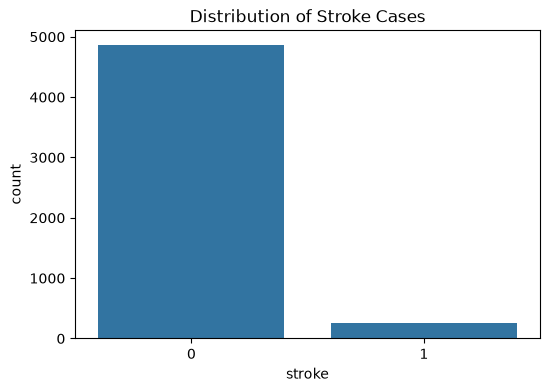

In [226]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="stroke")
plt.title("Distribution of Stroke Cases")
plt.show()

### Removing the ID Column


In [227]:
df.drop("id", axis=1, inplace=True)

### Handling Missing Values

In [228]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### Examining the BMI Distribution

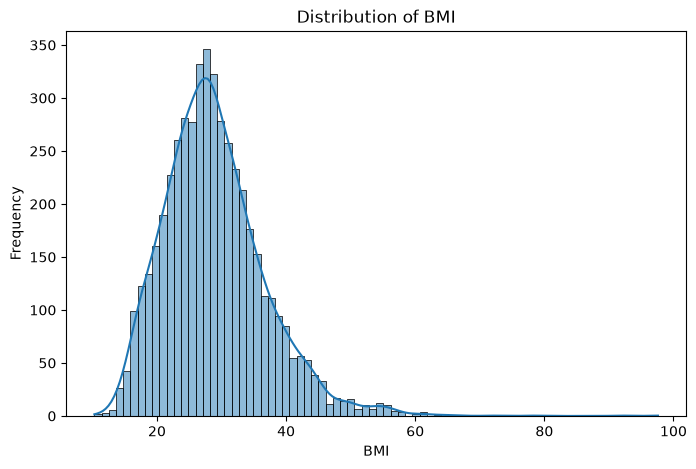

In [229]:
plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

### Filling the Missing Values

In [230]:
## Filling missing values
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [93]:
# Confirming the missing values are gone
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

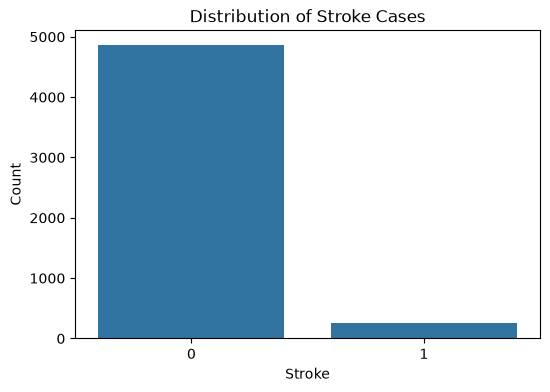

In [231]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="stroke")

plt.title("Distribution of Stroke Cases")
plt.xlabel("Stroke")
plt.ylabel("Count")

plt.show()

### Percentage Distribution of Stroke Cases

In [232]:
stroke_percentage = df["stroke"].value_counts(normalize=True) * 100

stroke_percentage

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

### Univariate Analysis

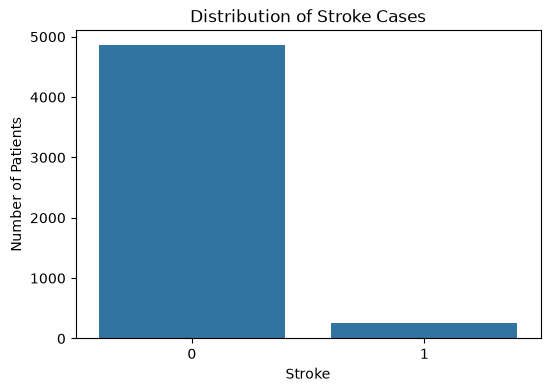

In [233]:
plt.figure(figsize=(6,4))

sns.countplot(x="stroke", data=df)

plt.title("Distribution of Stroke Cases")
plt.xlabel("Stroke")
plt.ylabel("Number of Patients")

plt.show()

In [234]:
(df["stroke"].value_counts(normalize=True) * 100).round(2)

stroke
0    95.13
1     4.87
Name: proportion, dtype: float64

### Checking the Distribution of Age


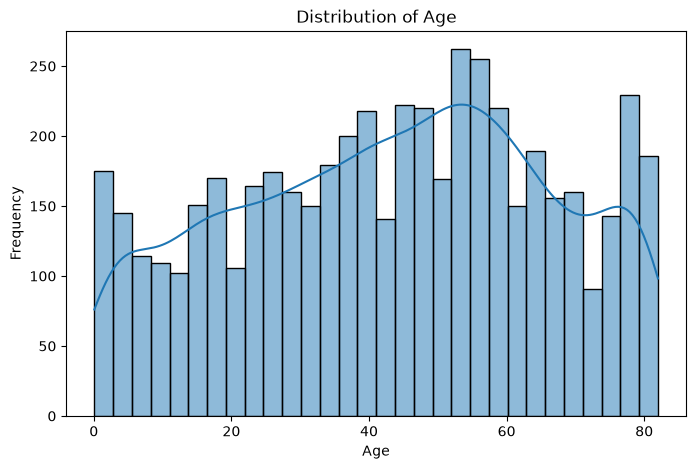

In [235]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Checking the BMI Distribution for Skewness

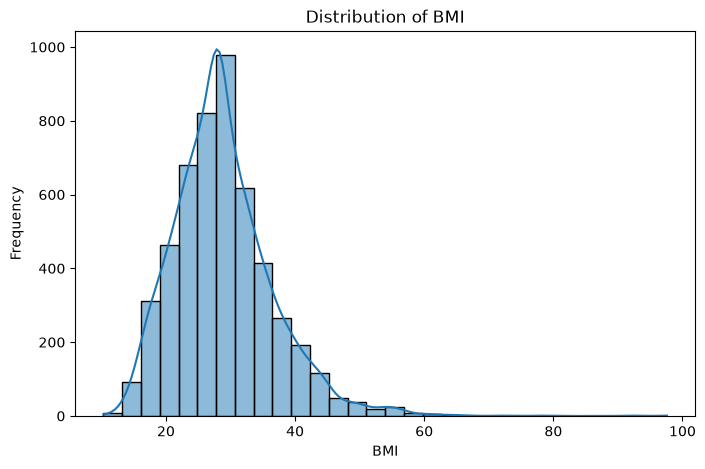

In [236]:
plt.figure(figsize=(8,5))

sns.histplot(df["bmi"], bins=30, kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

- Most patients have a BMI between 20 and 35. The distribution is positively skewed with a few high BMI values, indicating the presence of outliers.

### Average Glucose Level Distribution

- Average glucose level is an important health indicator that may influence stroke risk. Examining its distribution helps us understand how glucose levels vary among patients.

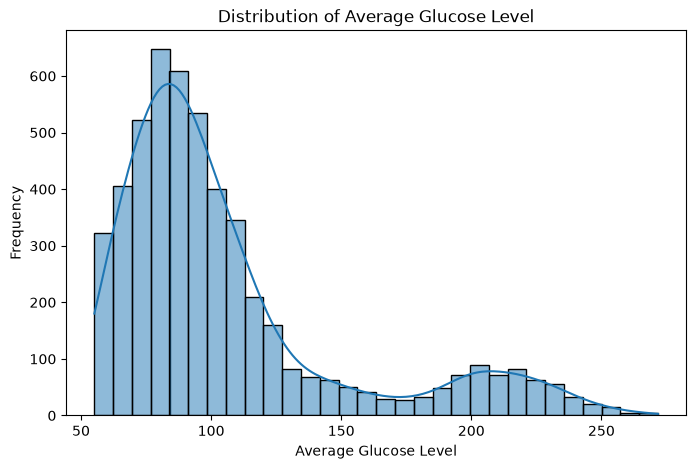

In [237]:
plt.figure(figsize=(8,5))

sns.histplot(df["avg_glucose_level"], bins=30, kde=True)

plt.title("Distribution of Average Glucose Level")
plt.xlabel("Average Glucose Level")
plt.ylabel("Frequency")

plt.show()

- Most patients have average glucose levels between 70 and 110. The distribution is positively skewed, with a small number of patients having much higher glucose levels. This indicates that while most patients have normal or moderately elevated glucose levels, a smaller group has significantly higher levels that may be associated with underlying health conditions.

## Bivariate Analysis

### Age vs Stroke


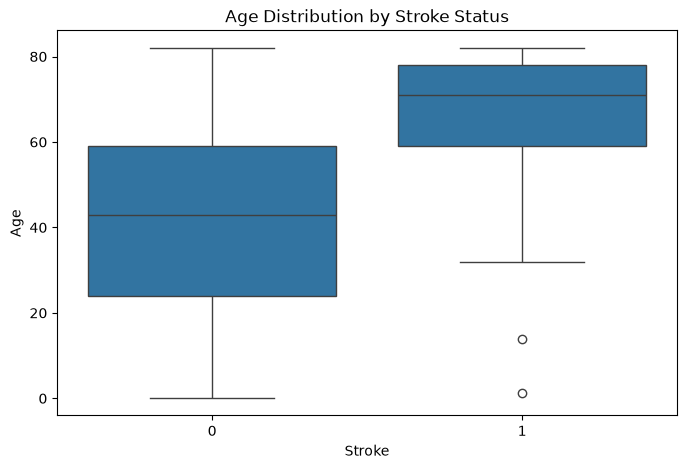

In [238]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="stroke", y="age")

plt.title("Age Distribution by Stroke Status")
plt.xlabel("Stroke")
plt.ylabel("Age")

plt.show()

- The boxplot shows that patients who experienced a stroke are generally older than those who did not. The median age of the stroke group is significantly higher, indicating that age may be an important predictor of stroke. Although a few younger patients experienced a stroke, most stroke cases occur among older adults.

### Hypertension vs Stroke


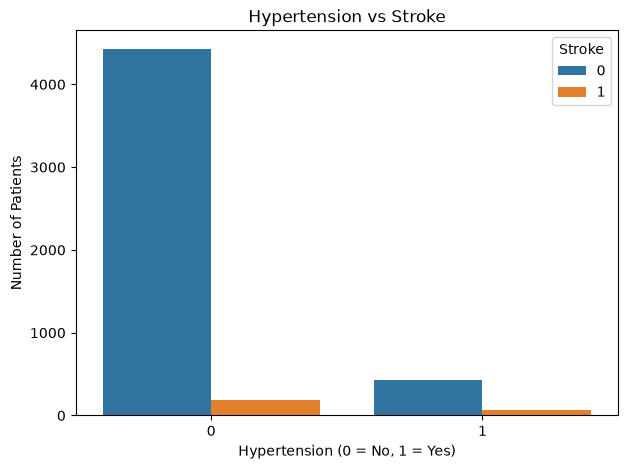

In [239]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="hypertension", hue="stroke")

plt.title("Hypertension vs Stroke")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.legend(title="Stroke")

plt.show()

- Most patients did not experience a stroke regardless of their hypertension status. However, stroke cases make up a larger proportion of patients with hypertension than those without hypertension. This suggests that hypertension may be an important predictor of stroke.

### Stroke Percentage by Hypertension Status


In [240]:
hypertension_percentage = pd.crosstab(
    df["hypertension"],
    df["stroke"],
    normalize="index"
) * 100

hypertension_percentage.round(2)

stroke,0,1
hypertension,,
0,96.03,3.97
1,86.75,13.25


### Heart Disease vs Stroke


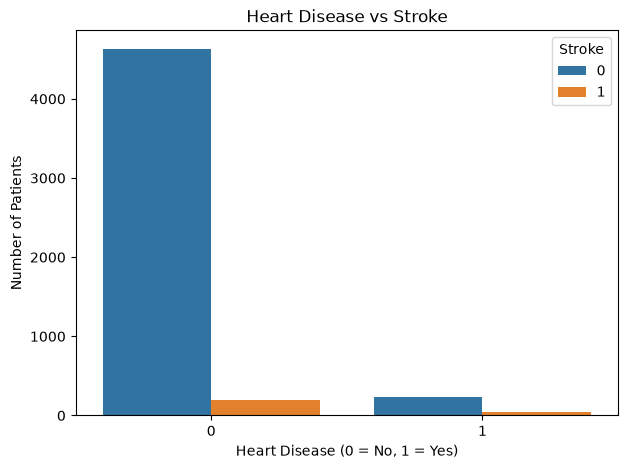

In [241]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="heart_disease", hue="stroke")

plt.title("Heart Disease vs Stroke")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.legend(title="Stroke")

plt.show()

In [242]:
heart_disease_percentage = pd.crosstab(
    df["heart_disease"],
    df["stroke"],
    normalize="index"
) * 100

heart_disease_percentage.round(2)

stroke,0,1
heart_disease,,
0,95.82,4.18
1,82.97,17.03


- The countplot shows that most patients did not have heart disease and did not experience a stroke. However, the percentage table reveals that 17.03% of patients with heart disease experienced a stroke, compared to only 4.18% of patients without heart disease. This suggests that heart disease is strongly associated with stroke occurrence and may be an important predictor in the model.

### BMI vs Stroke


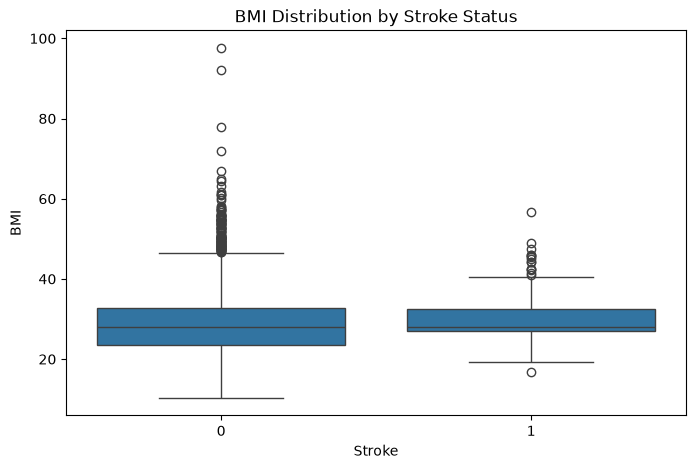

In [243]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="stroke", y="bmi")

plt.title("BMI Distribution by Stroke Status")
plt.xlabel("Stroke")
plt.ylabel("BMI")

plt.show()

### Average Glucose Level vs Stroke


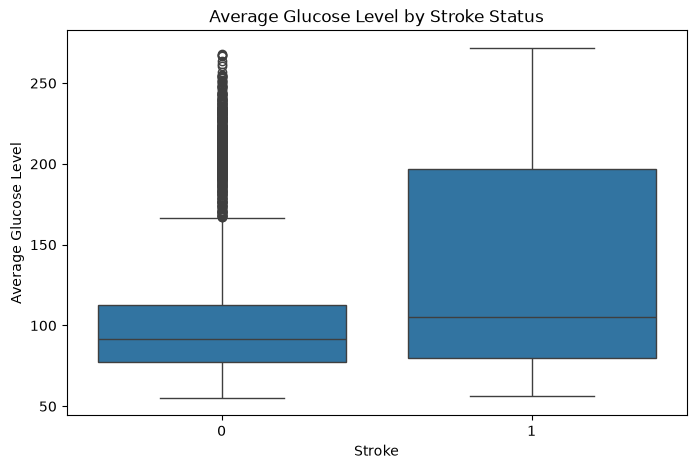

In [244]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="stroke", y="avg_glucose_level")

plt.title("Average Glucose Level by Stroke Status")
plt.xlabel("Stroke")
plt.ylabel("Average Glucose Level")

plt.show()

- The boxplot shows that patients who experienced a stroke generally have higher average glucose levels than those who did not. The stroke group has a higher median glucose level and a wider spread of values, suggesting that average glucose level may be an important predictor of stroke.
- Patients with stroke generally have higher average glucose levels than patients without stroke. This suggests that average glucose level may be a useful feature for predicting stroke.

### Smoking Status vs Stroke


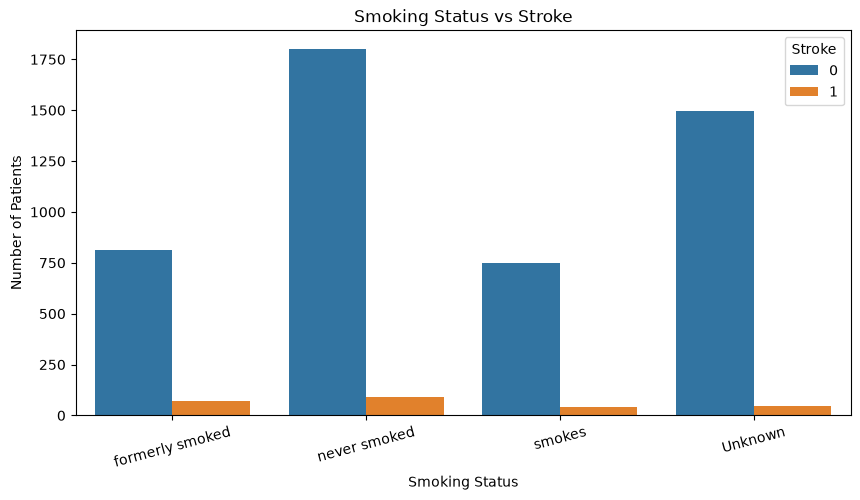

In [245]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="smoking_status", hue="stroke")

plt.title("Smoking Status vs Stroke")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")
plt.legend(title="Stroke")

plt.xticks(rotation=15)

plt.show()

In [246]:
smoking_percentage = pd.crosstab(
    df["smoking_status"],
    df["stroke"],
    normalize="index"
) * 100

smoking_percentage.round(2)

stroke,0,1
smoking_status,,
Unknown,96.96,3.04
formerly smoked,92.09,7.91
never smoked,95.24,4.76
smokes,94.68,5.32


- The percentage table shows that patients who formerly smoked have the highest proportion of stroke cases (7.91%), followed by current smokers (5.32%) and patients who never smoked (4.76%). However, this does not imply that quitting smoking causes stroke, as other factors such as age and existing medical conditions may also influence the results.

## Data Preprocessing

## Encoding The Categorical Variables

In [247]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [111]:
# Encode the Categorical Columns
categorical_columns = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

In [248]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Correlation Heatmap

In [265]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'Male'

<Figure size 1200x800 with 0 Axes>

## Train-Test Split

In [250]:
# Features
X = df.drop("stroke", axis=1)

# Target
y = df["stroke"]

In [251]:
# Import train_test_split
from sklearn.model_selection import train_test_split

In [253]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Feature Scaling

### Import StandardScaler

In [254]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

### Fit and Transform the Training Data

In [256]:
X_train = scaler.fit_transform(X_train)

ValueError: could not convert string to float: 'Female'

In [257]:
X_test = scaler.transform(X_test)

ValueError: could not convert string to float: 'Male'

## Handling Any Class Imbalance

In [258]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

### Viewing it in terms of percentages

In [259]:
stroke_percentage = df["stroke"].value_counts(normalize=True) * 100
stroke_percentage.round(2)

stroke
0    95.13
1     4.87
Name: proportion, dtype: float64

## Model Building and Evaluation for Each Model

## Logistic Regression
- It predicts the probability that a patient belongs to one of two classes

In [260]:
# Importing Logistic Regression
from sklearn.linear_model import LogisticRegression

In [261]:
# Creating the model
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

In [262]:
# Train the Model
log_model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Female'

In [124]:
# Make Predictions
y_pred_log = log_model.predict(X_test)

## Import Evaluation Metrics

In [125]:
# Importing Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [138]:
accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.7515
Precision: 0.1408
Recall   : 0.8000
F1-Score : 0.2395


### Logistic Regression Summary

The Logistic Regression model achieved an **accuracy of 75.15%**. It correctly identified **80% of patients who had a stroke**, demonstrating a high recall, which is important in healthcare because missing a stroke patient can have serious consequences.

However, the model had a **precision of 14.08%**, meaning many patients predicted to have a stroke did not actually have one. As a result, the **F1-score was 23.95%**, indicating that the balance between precision and recall can be improved.

Overall, Logistic Regression provides a good baseline model for this project and serves as a benchmark for comparing more advanced algorithms such as Decision Tree, Random Forest, and XGBoost.

## Decision Tree Classifier

In [263]:
# Importing decision tree
from sklearn.tree import DecisionTreeClassifier

In [128]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=5
)

In [129]:
# Training the model
dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [130]:
# Making predictions
y_pred_dt = dt_model.predict(X_test)

## Evaluation of Decision Tree Classifier

In [131]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-Score : {dt_f1:.4f}")

Accuracy : 0.8258
Precision: 0.1768
Recall   : 0.7000
F1-Score : 0.2823


In [132]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.83      0.90       972
           1       0.18      0.70      0.28        50

    accuracy                           0.83      1022
   macro avg       0.58      0.77      0.59      1022
weighted avg       0.94      0.83      0.87      1022



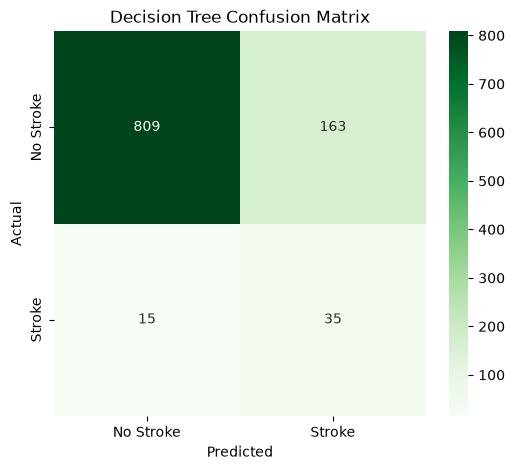

In [264]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Decision Tree Summary

The Decision Tree classifier was trained to predict whether a patient is likely to have a stroke based on their health and demographic information. Since the dataset contains far more non-stroke cases than stroke cases, the model was trained using `class_weight="balanced"` to give more importance to the minority class during learning.

After training, the model achieved:

- **Accuracy:** 82.58%
- **Precision:** 17.68%
- **Recall:** 70.00%
- **F1-Score:** 28.23%

The model correctly identified most patients without a stroke while also detecting **70% of the actual stroke cases**. Although the precision is relatively low, the higher recall is more important in healthcare because missing a patient who is at risk of a stroke can have serious consequences.


## Random Forest Classifier


In [134]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

In [136]:
# Training the Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [141]:
# Making Predictions
y_pred_rf = rf_model.predict(X_test)

### Evaluation of Random Forest Classifier

In [142]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

Accuracy : 0.9374
Precision: 0.2083
Recall   : 0.1000
F1-Score : 0.1351


## Evaluation of Random Forest Classifier

The Random Forest model achieved an accuracy of **93.74%**. Although this appears to be a strong result, the model struggled to identify patients who actually had a stroke.

The Recall was only **10%**, meaning that the model correctly detected only a small proportion of stroke cases. The Precision was **20.83%**, while the F1-Score was **13.51%**, indicating poor performance on the minority class.

The high accuracy is mainly due to the imbalanced dataset, where most patients do not have a stroke. As a result, the model tends to predict the majority class ("No Stroke") much more often than the minority class ("Stroke").

For healthcare applications, Recall is more important than Accuracy because missing patients who are at risk of a stroke can have serious consequences. Therefore, despite its high accuracy, the Random Forest model is not the best-performing model for this dataset.

## Hyperparameter Tuning - Logistic Regression


In [165]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [160]:
from sklearn.model_selection import GridSearchCV

In [161]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

In [162]:
grid_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

In [167]:
grid_lr.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

In [168]:
print("Best Parameters:")
print(grid_lr.best_params_)

Best Parameters:
{'C': 0.01, 'class_weight': 'balanced', 'solver': 'liblinear'}


In [187]:
best_lr = grid_lr.best_estimator_

In [188]:
y_pred_lr_best = best_lr.predict(X_test_scaled)

In [189]:
lr_accuracy = accuracy_score(y_test, y_pred_lr_best)
lr_precision = precision_score(y_test, y_pred_lr_best)
lr_recall = recall_score(y_test, y_pred_lr_best)
lr_f1 = f1_score(y_test, y_pred_lr_best)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")

Accuracy : 0.7221
Precision: 0.1274
Recall   : 0.8000
F1-Score : 0.2198


- Hyperparameter tuning was performed using GridSearchCV with recall as the optimization metric. Although different hyperparameters were identified, the tuned Logistic Regression model did not improve recall compared to the original model. Since the original model achieved the same recall with better overall performance (higher accuracy and F1-score), it was retained as the preferred Logistic Regression model.

### Hyperparameter Tuning - Decision Tree

In [179]:
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

In [183]:
from sklearn.model_selection import GridSearchCV

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.

In [181]:
print("Best Parameters:")
print(grid_dt.best_params_)

Best Parameters:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [185]:
# Save the best Decision Tree model
best_dt = grid_dt.best_estimator_

In [186]:
# Predictions using the tuned model
y_pred_dt_best = best_dt.predict(X_test)

In [190]:
# Evaluate the Model
dt_accuracy_best = accuracy_score(y_test, y_pred_dt_best)
dt_precision_best = precision_score(y_test, y_pred_dt_best)
dt_recall_best = recall_score(y_test, y_pred_dt_best)
dt_f1_best = f1_score(y_test, y_pred_dt_best)

print(f"Accuracy : {dt_accuracy_best:.4f}")
print(f"Precision: {dt_precision_best:.4f}")
print(f"Recall   : {dt_recall_best:.4f}")
print(f"F1-Score : {dt_f1_best:.4f}")

Accuracy : 0.6526
Precision: 0.1080
Recall   : 0.8400
F1-Score : 0.1913


In [191]:
print(classification_report(y_test, y_pred_dt_best))

              precision    recall  f1-score   support

           0       0.99      0.64      0.78       972
           1       0.11      0.84      0.19        50

    accuracy                           0.65      1022
   macro avg       0.55      0.74      0.49      1022
weighted avg       0.94      0.65      0.75      1022



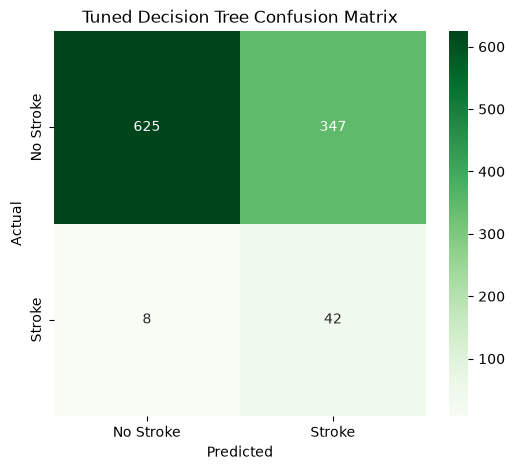

In [192]:
cm_dt_best = confusion_matrix(y_test, y_pred_dt_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt_best,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title("Tuned Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Hyperparameter Tuning - Random Forest

In [193]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

In [194]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.

In [195]:
print("Best Parameters:")
print(grid_rf.best_params_)

Best Parameters:
{'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [196]:
best_rf = grid_rf.best_estimator_

In [197]:
y_pred_rf_best = best_rf.predict(X_test)

In [198]:
rf_accuracy_best = accuracy_score(y_test, y_pred_rf_best)
rf_precision_best = precision_score(y_test, y_pred_rf_best)
rf_recall_best = recall_score(y_test, y_pred_rf_best)
rf_f1_best = f1_score(y_test, y_pred_rf_best)

print(f"Accuracy : {rf_accuracy_best:.4f}")
print(f"Precision: {rf_precision_best:.4f}")
print(f"Recall   : {rf_recall_best:.4f}")
print(f"F1-Score : {rf_f1_best:.4f}")

Accuracy : 0.6341
Precision: 0.1029
Recall   : 0.8400
F1-Score : 0.1834


In [199]:
print(classification_report(y_test, y_pred_rf_best))


              precision    recall  f1-score   support

           0       0.99      0.62      0.76       972
           1       0.10      0.84      0.18        50

    accuracy                           0.63      1022
   macro avg       0.54      0.73      0.47      1022
weighted avg       0.94      0.63      0.74      1022



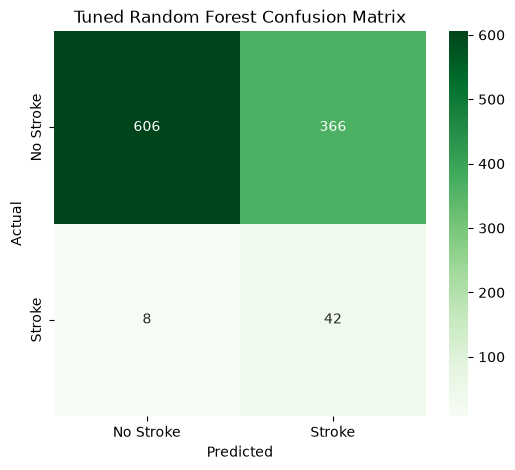

In [200]:
cm_rf_best = confusion_matrix(y_test, y_pred_rf_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf_best,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## XGBoost Classifier

In [201]:
#Import XG Boost
from xgboost import XGBClassifier

In [202]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [203]:
grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=xgb_param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose

In [204]:
print("Best Parameters:")
print(grid_xgb.best_params_)

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [205]:
best_xgb = grid_xgb.best_estimator_

In [206]:
y_pred_xgb = best_xgb.predict(X_test)

In [207]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")

Accuracy : 0.9442
Precision: 0.2308
Recall   : 0.0600
F1-Score : 0.0952


In [208]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.23      0.06      0.10        50

    accuracy                           0.94      1022
   macro avg       0.59      0.52      0.53      1022
weighted avg       0.92      0.94      0.93      1022



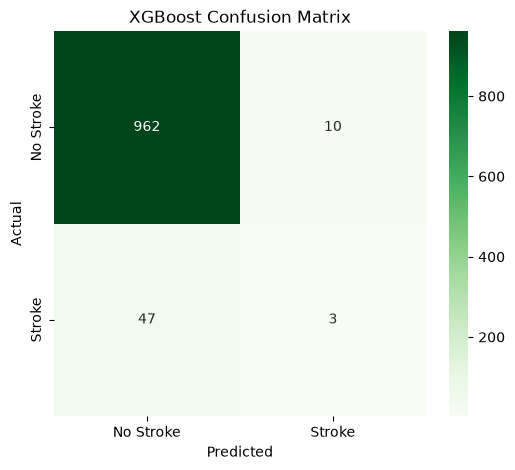

In [209]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Comparison

The performance of the four machine learning algorithms is compared using Accuracy, Precision, Recall and F1-Score.

Since this is a healthcare application, Recall is given the highest priority because correctly identifying stroke patients is more important than maximizing overall accuracy.

In [212]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy_best,
        rf_accuracy_best,
        xgb_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision_best,
        rf_precision_best,
        xgb_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall_best,
        rf_recall_best,
        xgb_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1_best,
        rf_f1_best,
        xgb_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.722114,0.127389,0.80,0.219780
1,Decision Tree,0.652642,0.107969,0.84,0.191344
2,Random Forest,0.634051,0.102941,0.84,0.183406
3,XGBoost,0.944227,0.230769,0.06,0.095238


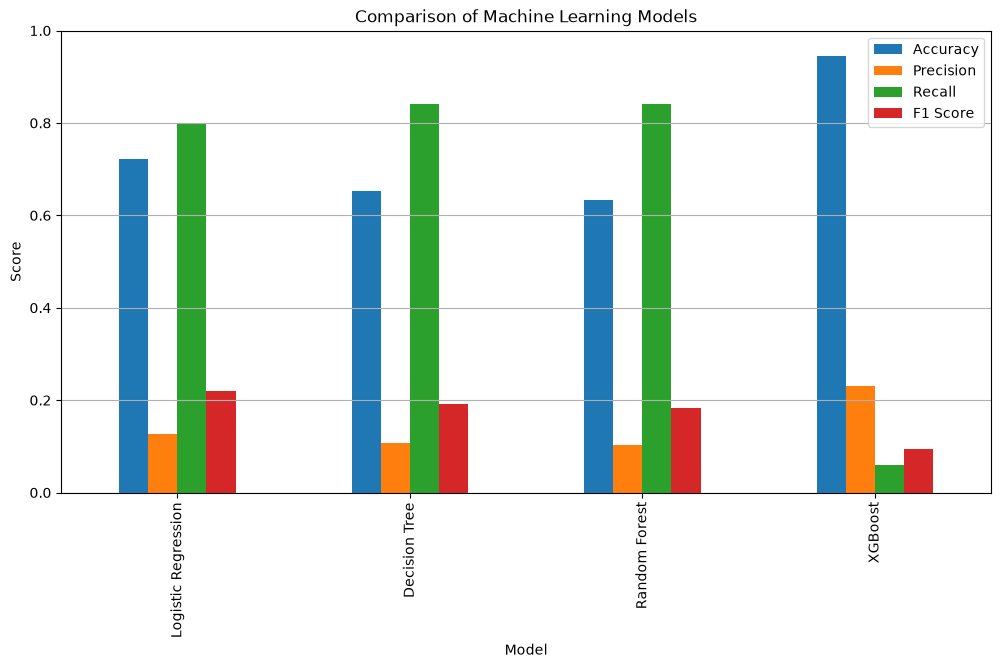

In [213]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.ylim(0,1)

plt.grid(axis="y")

plt.show()

# Final Model Selection

Four machine learning models were trained and evaluated for stroke prediction:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Although XGBoost achieved the highest accuracy, it performed poorly in identifying stroke patients, with a recall of only 6%.

The Decision Tree and Random Forest achieved the highest recall (84%), but they produced a large number of false positives, resulting in low precision and F1-scores.

Logistic Regression achieved the best overall balance between recall, precision, and F1-score. It correctly identified 80% of stroke cases while maintaining the highest F1-score among all the models evaluated.

Since this is a healthcare application where missing stroke patients is more costly than generating false alarms, Logistic Regression was selected as the final prediction model.

In [214]:
final_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy_best,
        rf_accuracy_best,
        xgb_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision_best,
        rf_precision_best,
        xgb_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall_best,
        rf_recall_best,
        xgb_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1_best,
        rf_f1_best,
        xgb_f1
    ]

})

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7221,0.1274,0.80,0.2198
1,Decision Tree,0.6526,0.1080,0.84,0.1913
2,Random Forest,0.6341,0.1029,0.84,0.1834
3,XGBoost,0.9442,0.2308,0.06,0.0952


# Predicting Stroke for a New Patient

The selected Logistic Regression model is now used to predict whether a new patient is likely to experience a stroke.

The patient information is entered as a feature vector using the same feature order that was used during model training.

In [215]:
new_patient = pd.DataFrame({

    "gender":[1],
    "age":[67],
    "hypertension":[0],
    "heart_disease":[1],
    "ever_married":[1],
    "work_type":[2],
    "Residence_type":[1],
    "avg_glucose_level":[228.69],
    "bmi":[36.6],
    "smoking_status":[1]

})

In [216]:
new_patient_scaled = scaler.transform(new_patient)

/home/marlicd/Projects/Machine_Learning/Machine_Learning_Capstone/project/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [217]:
prediction = best_lr.predict(new_patient_scaled)

print(prediction)

[1]


In [218]:
if prediction[0] == 1:
    print("The model predicts that the patient is likely to experience a stroke.")
else:
    print("The model predicts that the patient is unlikely to experience a stroke.")

The model predicts that the patient is likely to experience a stroke.


In [219]:
probability = best_lr.predict_proba(new_patient_scaled)

print(probability)

[[0. 1.]]


In [220]:
probability = best_lr.predict_proba(new_patient_scaled)

print(probability)
print(probability[0])
print(f"No Stroke Probability: {probability[0][0]:.10f}")
print(f"Stroke Probability   : {probability[0][1]:.10f}")

[[0. 1.]]
[0. 1.]
No Stroke Probability: 0.0000000000
Stroke Probability   : 1.0000000000
